<a href="https://colab.research.google.com/github/rautsahil02/CSL701-38_Machine-Learning-Lab-/blob/main/EXPERIMENT/ML_Experiment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name : SAHil SANJAY RAUT

Batch : 03


Roll Number : CE38



Aim

To implement Principal Component Analysis (PCA) for dimensionality reduction on the Breast Cancer Wisconsin (Diagnostic) dataset, visualize the high-dimensional feature space in a reduced 2D plane, and evaluate its impact on classification performance.

## Objectives

1. To understand the concepts of dimensionality reduction, feature correlation, and Principal Component Analysis.

2. To preprocess, clean, and scale high-dimensional real-world data using StandardScaler.

3. To implement PCA using Python to compress feature dimensions from 30 continuous features down to 2 principal components.

4. To calculate and plot the explained variance ratio and cumulative explained variance.

5. To visualize the transformed 2D dataset and analyze class separability.

6. To evaluate and compare classification model performance (e.g., Logistic Regression) before and after applying PCA.

# Relevant Theory

### Support Vector Machine

Principal Component Analysis (PCA)Principal Component Analysis (PCA) is an unsupervised machine learning technique used for dimensionality reduction. It transforms a dataset containing a large set of correlated features into a smaller set of uncorrelated variables called Principal Components ($PCs$), while preserving as much data variance as possible.

Mathematical Steps:

1. Standardization: Scale each feature to have a mean of 0 ($\mu = 0$) and standard deviation of 1 ($\sigma = 1$).

2. Covariance Matrix: Compute the covariance matrix $C$ to quantify feature correlations:$$C = \frac{1}{n-1} X^T X$$

3. Eigen decomposition: Compute eigenvalues ($\lambda$) and eigenvectors ($v$) of matrix $C$:$$C v = \lambda v$$

    * Eigenvectors represent the direction of the principal axes.
    * Eigenvalues indicate the amount of variance along those axes.
4. Projection: Project original data $X$ onto top $k$ principal component directions $W$:$$X_{\text{pca}} = X \cdot W$$

###Dataset Information


1. Dataset Name: Breast Cancer Wisconsin (Diagnostic) Dataset

2. Kaggle Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

3. Classes: 2 binary classes (Malignant [$M$] and Benign [$B$])

4. Features: 30 continuous features computed from digitized images of fine needle aspirates (FNA) of a breast mass (e.g., radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, concavity_mean, etc.).

5. Non-Feature Columns: id (identifier) and Unnamed: 32 (empty column).

# Task 1: Import Libraries and Load Dataset

Import core Python libraries (numpy, pandas, matplotlib, seaborn, sklearn) and load data.csv obtained from Kaggle.

---

In [3]:
# Task 1: Import Libraries and Upload Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Upload dataset
from google.colab import files

uploaded = files.upload()

# Load the uploaded CSV file
df = pd.read_csv("data.csv")

# Display first 5 rows
df.head()


Saving data.csv to data.csv


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Task 2: Explore the Dataset

Inspect missing values, view dataset summary statistics, check column data types, and inspect target class distributions (diagnosis).

Dataset Shape: (569, 33)

Column Names:
Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

Data Types:
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
co

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN



Diagnosis Distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64


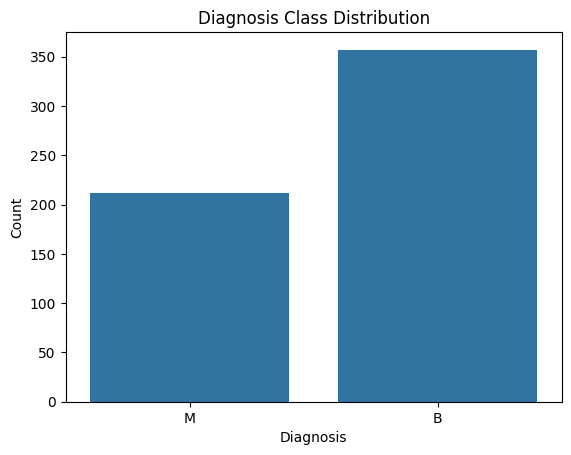

In [4]:
# Task 2: Explore the Dataset

# Display dataset shape
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns)

# Display data types
print("\nData Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Display statistical summary
print("\nStatistical Summary:")
display(df.describe())

# Check target class distribution
print("\nDiagnosis Distribution:")
print(df["diagnosis"].value_counts())

# Visualize class distribution
sns.countplot(x="diagnosis", data=df)
plt.title("Diagnosis Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()


# Task 3: Data Cleaning and Feature/Target Selection

Drop metadata columns (id and Unnamed: 32). Convert the categorical target column (diagnosis: 'M'/'B') into numerical values (1/0) and separate feature matrix $X$ (30 features) from label vector $y$.   

In [5]:
# Task 3: Data Cleaning and Feature/Target Selection

# Drop unnecessary columns
df_clean = df.drop(columns=["id", "Unnamed: 32"])

# Convert diagnosis:
# M = 1 (Malignant)
# B = 0 (Benign)
df_clean["diagnosis"] = df_clean["diagnosis"].map({
    "M": 1,
    "B": 0
})

# Separate features and target
X = df_clean.drop(columns=["diagnosis"])
y = df_clean["diagnosis"]

# Display shapes
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

# Display feature names
print("\nFeatures:")
print(X.columns.tolist())

# Display first 5 rows
display(X.head())

# Display target values
print("\nTarget Values:")
print(y.head())


Feature Matrix Shape: (569, 30)
Target Shape: (569,)

Features:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Target Values:
0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64


# Task 4: Standardize Features

Apply StandardScaler to transform all 30 numeric features so they have zero mean and unit variance ($\mu=0, \sigma=1$).

In [6]:
# Task 4: Standardize Features

# Create StandardScaler object
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easy viewing
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

# Display first 5 standardized rows
display(X_scaled_df.head())

# Check mean and standard deviation
print("Mean of standardized features:")
print(X_scaled_df.mean().round(2))

print("\nStandard deviation of standardized features:")
print(X_scaled_df.std().round(2))


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


Mean of standardized features:
radius_mean               -0.0
texture_mean               0.0
perimeter_mean            -0.0
area_mean                 -0.0
smoothness_mean           -0.0
compactness_mean           0.0
concavity_mean             0.0
concave points_mean       -0.0
symmetry_mean              0.0
fractal_dimension_mean     0.0
radius_se                  0.0
texture_se                -0.0
perimeter_se              -0.0
area_se                   -0.0
smoothness_se             -0.0
compactness_se             0.0
concavity_se               0.0
concave points_se          0.0
symmetry_se                0.0
fractal_dimension_se      -0.0
radius_worst              -0.0
texture_worst              0.0
perimeter_worst           -0.0
area_worst                 0.0
smoothness_worst          -0.0
compactness_worst         -0.0
concavity_worst            0.0
concave points_worst       0.0
symmetry_worst             0.0
fractal_dimension_worst   -0.0
dtype: float64

Standard deviation of s

# Task 5: Implement PCA (30D to 2D)

Use sklearn.decomposition.PCA to reduce feature dimensions from 30 down to 2 principal components ($PC_1$ and $PC_2$).

In [7]:
# Task 5: Implement PCA (30D to 2D)

# Create PCA object with 2 components
pca = PCA(n_components=2)

# Fit PCA and transform the standardized data
X_pca = pca.fit_transform(X_scaled)

# Create DataFrame for PCA results
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

# Add diagnosis to the PCA DataFrame
pca_df["Diagnosis"] = y.values

# Display first 5 rows
display(pca_df.head())

# Display shape
print("Original Feature Shape:", X_scaled.shape)
print("PCA Feature Shape:", X_pca.shape)


,PC1,PC2,Diagnosis
0,9.192837,1.948583,1
1,2.387802,-3.768172,1
2,5.733896,-1.075174,1
3,7.122953,10.275589,1
4,3.935302,-1.948072,1


Original Feature Shape: (569, 30)
PCA Feature Shape: (569, 2)


# Task 6: Analyze Explained Variance Ratio

Compute and print the variance explained by $PC_1$ and $PC_2$, along with the cumulative variance retained.


Explained Variance Ratio:
PC1: 0.44272025607526366
PC2: 0.18971182044033078

Cumulative Explained Variance:
PC1: 0.44272025607526366
PC1 + PC2: 0.6324320765155944

Explained Variance Percentage:
PC1: 44.27%
PC2: 18.97%
PC1 + PC2: 63.24%


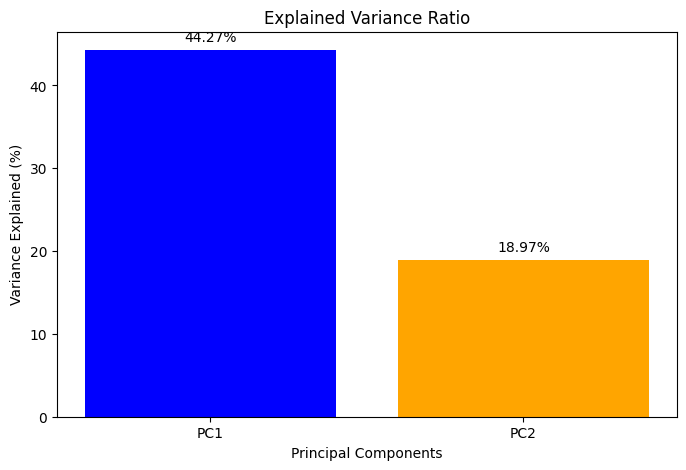

In [9]:
# Task 6: Analyze Explained Variance Ratio

# Explained variance ratio for PC1 and PC2
explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
print("PC1:", explained_variance[0])
print("PC2:", explained_variance[1])

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

print("\nCumulative Explained Variance:")
print("PC1:", cumulative_variance[0])
print("PC1 + PC2:", cumulative_variance[1])

# Convert to percentage
print("\nExplained Variance Percentage:")
print("PC1: {:.2f}%".format(explained_variance[0] * 100))
print("PC2: {:.2f}%".format(explained_variance[1] * 100))
print("PC1 + PC2: {:.2f}%".format(cumulative_variance[1] * 100))

# Plot explained variance

components = ["PC1", "PC2"]

plt.figure(figsize=(8, 5))
plt.bar(
    components,
    explained_variance * 100,
    color=["blue", "orange"]
)

plt.title("Explained Variance Ratio")
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained (%)")

for i, value in enumerate(explained_variance * 100):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()



# Task 7: Visualize PCA Transformed Boundary / Scatter Plot

Create a 2D scatter plot with $PC_1$ on the x-axis and $PC_2$ on the y-axis, hue-coded by tumor diagnosis (Malignant vs. Benign).

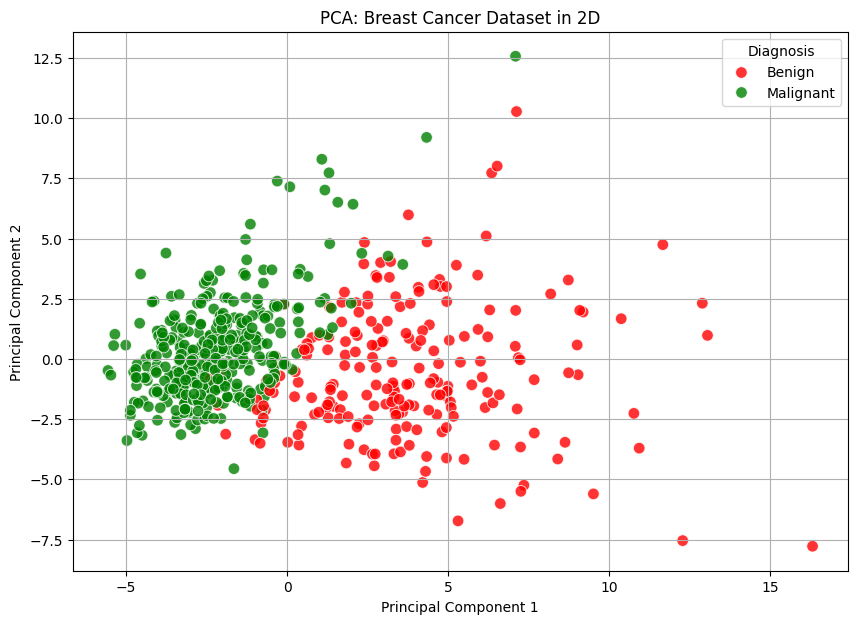

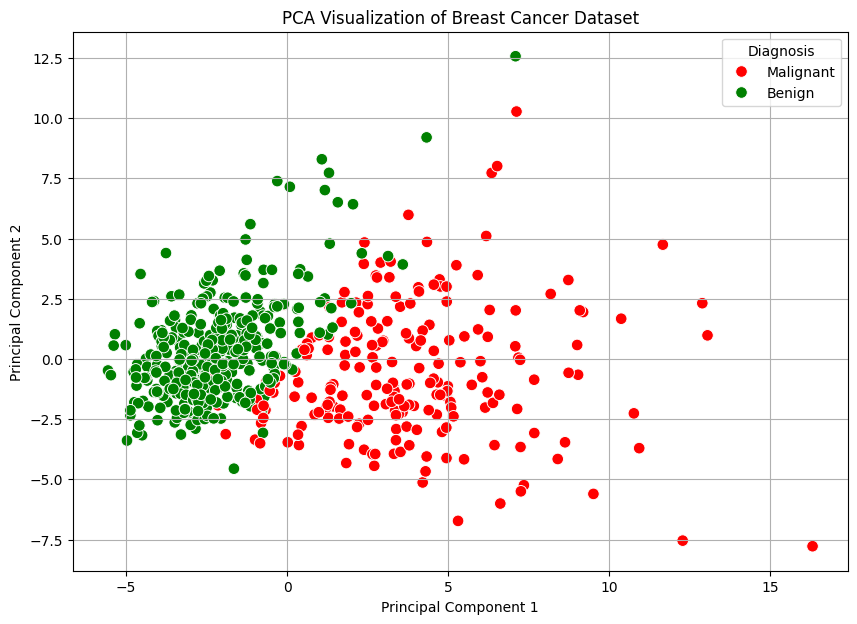

In [10]:
# Task 7: Visualize PCA Transformed 2D Data

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Diagnosis",
    data=pca_df,
    palette={
        0: "green",
        1: "red"
    },
    s=70,
    alpha=0.8
)

plt.title("PCA: Breast Cancer Dataset in 2D")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(
    title="Diagnosis",
    labels=["Benign", "Malignant"]
)

plt.grid(True)
plt.show()
# Create readable diagnosis labels

pca_plot_df = pca_df.copy()

pca_plot_df["Diagnosis"] = pca_plot_df["Diagnosis"].map({
    0: "Benign",
    1: "Malignant"
})

plt.figure(figsize=(10, 7))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Diagnosis",
    data=pca_plot_df,
    palette={
        "Benign": "green",
        "Malignant": "red"
    },
    s=70
)

plt.title("PCA Visualization of Breast Cancer Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()


# Task 8: Train Classifier on Raw High-Dimensional Data (30 Features)

Split the original scaled 30-feature dataset into training and testing sets. Train a Logistic Regression model and obtain baseline performance metrics.

In [11]:
# Task 8: Logistic Regression on Original 30 Features

# Split original standardized data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)

# Train model
logistic_model.fit(X_train, y_train)

# Make predictions
y_pred = logistic_model.predict(X_test)

# Calculate accuracy
accuracy_raw = accuracy_score(y_test, y_pred)

print("Logistic Regression - Original 30 Features")
print("Accuracy:", accuracy_raw)

# Confusion Matrix
cm_raw = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm_raw)

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Benign", "Malignant"]
))


Logistic Regression - Original 30 Features
Accuracy: 0.9649122807017544

Confusion Matrix:
[[71  1]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



# Task 9: Train Classifier on PCA Transformed Data (2 Features)

Split the 2-component PCA dataset into training and testing sets. Train a Logistic Regression model using only $PC_1$ and $PC_2$.

In [12]:
# Task 9: Logistic Regression on PCA 2 Features

# Split PCA data
X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Logistic Regression model
pca_logistic_model = LogisticRegression(max_iter=1000)

# Train model
pca_logistic_model.fit(X_pca_train, y_pca_train)

# Make predictions
y_pca_pred = pca_logistic_model.predict(X_pca_test)

# Calculate accuracy
accuracy_pca = accuracy_score(y_pca_test, y_pca_pred)

print("Logistic Regression - PCA 2 Features")
print("Accuracy:", accuracy_pca)

# Confusion Matrix
cm_pca = confusion_matrix(y_pca_test, y_pca_pred)

print("\nConfusion Matrix:")
print(cm_pca)

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_pca_test,
    y_pca_pred,
    target_names=["Benign", "Malignant"]
))


Logistic Regression - PCA 2 Features
Accuracy: 0.9385964912280702

Confusion Matrix:
[[71  1]
 [ 6 36]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



# Task 10: Compare Classifier Performance

Compare the performance of the model before PCA (30 features) vs. after PCA (2 components) using:   

*   Accuracy Score
*   Confusion Matrix
*   Classification Report (Precision, Recall, F1-Score)  



========== MODEL PERFORMANCE COMPARISON ==========

Accuracy using Original 30 Features:
0.9649

Accuracy using PCA 2 Features:
0.9386

Accuracy Difference:
0.0263


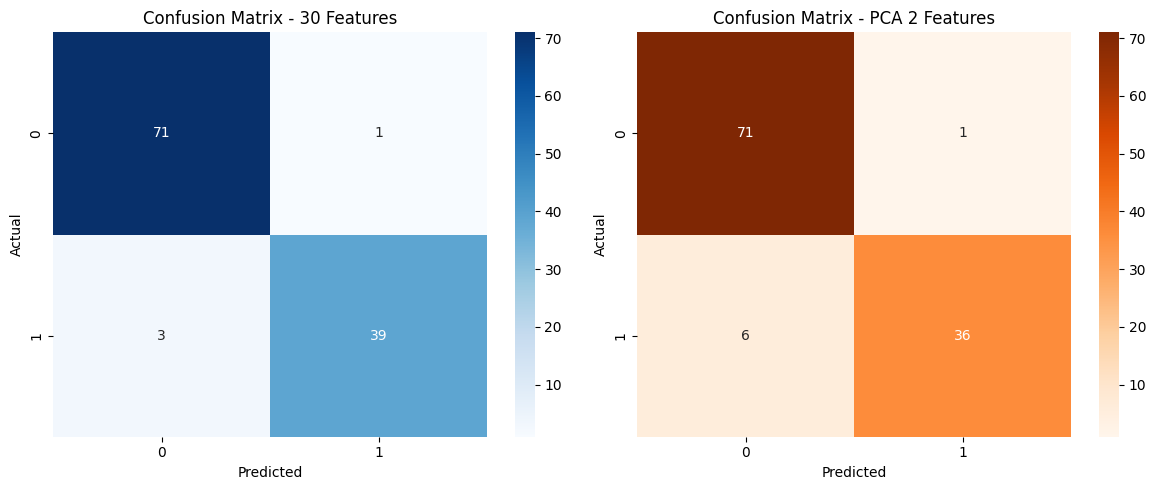

Classification Report - Original 30 Features
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Classification Report - PCA 2 Features
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



,Model,Number of Features,Accuracy
0,Logistic Regression - 30 Features,30,0.964912
1,Logistic Regression - PCA 2 Features,2,0.938596


In [14]:
# Task 10: Compare Performance Before and After PCA

print("========== MODEL PERFORMANCE COMPARISON ==========\n")

print("Accuracy using Original 30 Features:")
print(f"{accuracy_raw:.4f}")

print("\nAccuracy using PCA 2 Features:")
print(f"{accuracy_pca:.4f}")

print("\nAccuracy Difference:")
print(f"{accuracy_raw - accuracy_pca:.4f}")
# Plot confusion matrices

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original features
sns.heatmap(
    cm_raw,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0]
)

axes[0].set_title("Confusion Matrix - 30 Features")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# PCA features
sns.heatmap(
    cm_pca,
    annot=True,
    fmt="d",
    cmap="Oranges",
    ax=axes[1]
)

axes[1].set_title("Confusion Matrix - PCA 2 Features")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()
# Classification Report - Original 30 Features

print("Classification Report - Original 30 Features")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Benign", "Malignant"]
    )
)

# Classification Report - PCA 2 Features

print("\nClassification Report - PCA 2 Features")
print("=" * 50)

print(
    classification_report(
        y_pca_test,
        y_pca_pred,
        target_names=["Benign", "Malignant"]
    )
)
# Final Model Comparison

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression - 30 Features",
        "Logistic Regression - PCA 2 Features"
    ],
    "Number of Features": [
        30,
        2
    ],
    "Accuracy": [
        accuracy_raw,
        accuracy_pca
    ]
})

display(comparison)



# Conclusion

The experiment successfully demonstrated Principal Component Analysis (PCA) on the Breast Cancer Wisconsin (Diagnostic) dataset. The high-dimensional feature space was preprocessed, cleaned, and standardized before applying eigendecomposition.

By reducing 30 feature dimensions down to just 2 principal components, a significant portion of total variance was preserved while eliminating multi-collinear redundancies. Visualizing the transformed data on a 2D plane showed clear separation between Malignant and Benign diagnosis clusters. Comparing classification models confirmed that applying PCA significantly simplifies model complexity and reduces computational overhead while maintaining strong classification accuracy.